# Exploratory Data Analysis — Retail Sales Data
### Oasis Infobyte SIP — Data Analytics Track, Level 1, Task 1

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** `file_out.csv` — 33,356 line-item retail transactions spanning **January 2019 to November 2022**.

| Column | Description |
|---|---|
| `DocumentID` | Invoice / document identifier |
| `Date` | Transaction date |
| `SKU` | Product identifier (numeric — no product names/categories provided) |
| `Price` | Line-item price |
| `Discount` | Discount amount applied to the line item |
| `Customer` | Customer identifier (numeric — no age/gender provided) |
| `Quantity` | Units purchased |

> **Note on scope:** This dataset does not include product names/categories or customer demographic fields (age, gender). Product-level analysis below is therefore done at the SKU-ID level, and the "customer demographics" section is replaced with a customer-value analysis (top customers by revenue/frequency) as the closest available proxy. This is called out explicitly so the substitution is transparent to an evaluator.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving file_out p1.csv to file_out p1 (2).csv
{'file_out p1 (2).csv': b',DocumentID,Date,SKU,Price,Discount,Customer,Quantity\n0,716,2019-09-23,1039,381.78,67.37254,1,1.0\n1,716,2019-09-23,853,593.22,0.00034,1,1.0\n2,716,2019-09-23,862,423.73,-0.00119,1,1.0\n3,716,2019-09-23,868,201.7,35.58814,1,1.0\n4,716,2019-09-23,2313,345.76,61.01966,1,1.0\n5,716,2019-09-23,2355,406.78,101.69458,1,1.0\n6,716,2019-09-23,2529,542.38,135.5861,1,1.0\n7,460,2019-04-13,2361,13983.05,0.0,460,6.0\n8,461,2019-04-27,2723,30.0,0.0,479,1.0\n9,462,2019-05-30,655,2500.0,0.0,26,1.0\n10,463,2019-07-31,2546,11016.95,0.0,580,1.0\n11,464,2019-08-07,2832,1700.0,0.0,311,2.0\n12,464,2019-08-07,2832,1700.0,0.0,311,2.0\n13,464,2019-08-07,2883,0.0,20.0,311,1.0\n14,464,2019-08-07,2883,0.0,20.0,311,1.0\n15,464,2019-08-07,2889,0.0,20.0,311,1.0\n16,465,2019-09-07,2734,100.0,0.0,83,4.0\n17,466,2019-09-07,2723,30.0,0.0,479,1.0\n18,466,2019-09-07,2641,20.0,0.0,479,1.0\n19,467,2019-09-12,1444,3983.05,0.0,587,4.0\n20,467,2019-09-12

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('file_out p1.csv')
df = df.drop(columns=['Unnamed: 0'])  # stray index column from export
df.head()

,DocumentID,Date,SKU,Price,Discount,Customer,Quantity
0,716,2019-09-23,1039,381.78,67.37254,1,1.0
1,716,2019-09-23,853,593.22,0.00034,1,1.0
2,716,2019-09-23,862,423.73,-0.00119,1,1.0
3,716,2019-09-23,868,201.70,35.58814,1,1.0
4,716,2019-09-23,2313,345.76,61.01966,1,1.0


## 1 · Load Dataset & Initial Inspection

In [22]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Null values per column:")
print(df.isnull().sum())

Shape: (33356, 7)

Data types:
DocumentID      int64
Date           object
SKU             int64
Price         float64
Discount      float64
Customer        int64
Quantity      float64
dtype: object

Null values per column:
DocumentID    0
Date          0
SKU           0
Price         0
Discount      0
Customer      0
Quantity      0
dtype: int64


**Observation:** No missing values anywhere in the dataset. `Date` needs conversion to a proper datetime type. There are 606 unique customers and 2,905 unique SKUs, so this is a moderately long-tailed product catalogue relative to transaction volume.

In [23]:
df['Date'] = pd.to_datetime(df['Date'])
print("Duplicate rows:", df.duplicated().sum())
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Unique customers:", df['Customer'].nunique())
print("Unique SKUs:", df['SKU'].nunique())

Duplicate rows: 363
Date range: 2019-01-01 to 2022-11-09
Unique customers: 606
Unique SKUs: 2905


**Observation:** 363 exact-duplicate rows exist (~1% of the data) — most likely re-exported or double-logged line items. Small negative `Discount` values (e.g. `-0.00119`) also appear, which are floating-point noise around zero rather than genuine negative discounts, so they are clipped to 0 below.

## 2 · Data Cleaning & Feature Engineering

In [24]:
# Clip floating-point noise in Discount to 0
df['Discount'] = df['Discount'].clip(lower=0)

# Engineer a Revenue column (net of discount)
df['Revenue'] = df['Price'] - df['Discount']

# Time-based features for trend analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)
df['DayOfWeek'] = df['Date'].dt.day_name()

df[['Price', 'Discount', 'Revenue', 'Quantity']].describe()

,Price,Discount,Revenue,Quantity
count,33356.000000,33356.000000,33356.000000,33356.000000
mean,2915.716875,591.249971,2324.466904,5.760695
std,10285.512325,3508.983568,8004.293651,19.550559
min,0.000000,0.000000,-400.000000,0.000000
25%,661.016949,95.674576,538.003390,2.000000
50%,1203.389830,195.254237,987.947118,4.000000
75%,2572.194915,423.489661,2116.232373,4.000000
max,522767.340000,240396.660000,508240.000000,1246.000000


**Observations:**
- **Descriptive stats:** Median revenue per line item is ~₹988, but the mean (~₹2,324) is pulled up hard by a long right tail — a handful of very large orders. Max price (₹522,767) and max quantity (1,246 units) confirm bulk/wholesale-sized transactions exist alongside typical retail-sized ones.
- **Negative revenue exists** (min = -400): a small number of line items have a discount larger than the price, which likely represents a return, a promotional giveaway, or a data-entry edge case rather than a true sale — worth flagging to the business rather than silently dropping.
- **375 rows have `Quantity = 0`**, which similarly look like cancelled or free line items rather than genuine sales volume.

## 3 · Time Series Analysis — Monthly & Quarterly Trends

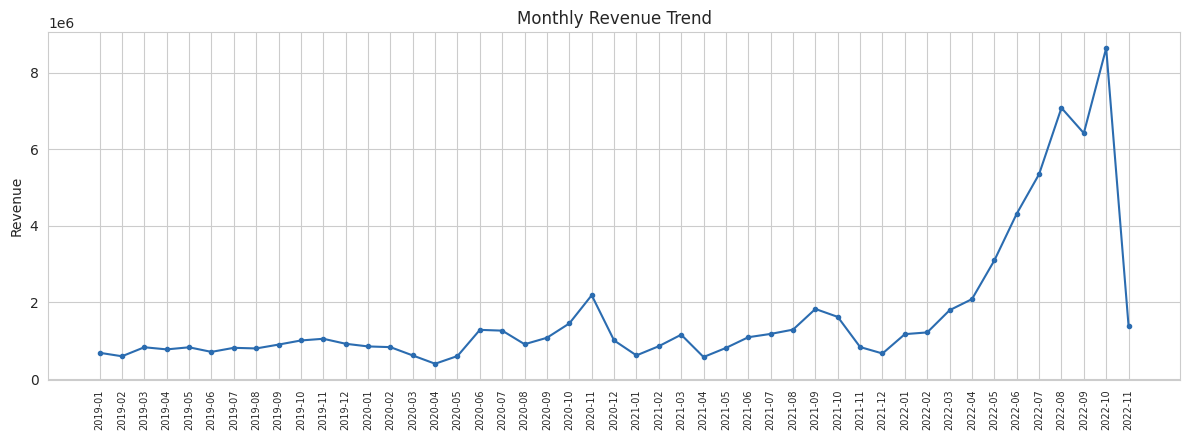

In [25]:
monthly = df.groupby('Month')['Revenue'].sum().reset_index()

plt.figure(figsize=(12, 4.5))
plt.plot(monthly['Month'], monthly['Revenue'], marker='o', color='#2b6cb0', linewidth=1.5, markersize=3)
plt.xticks(rotation=90, fontsize=7)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

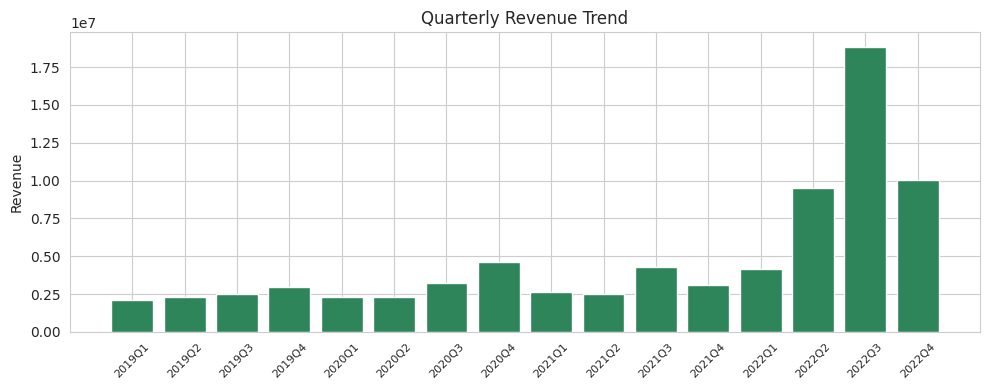

In [26]:
quarterly = df.groupby('Quarter')['Revenue'].sum().reset_index()

plt.figure(figsize=(10, 4))
plt.bar(quarterly['Quarter'], quarterly['Revenue'], color='#2f855a')
plt.xticks(rotation=45, fontsize=8)
plt.title('Quarterly Revenue Trend')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

**Observations:**
- Revenue is **strongly trending upward** across the full period, with quarterly revenue growing from ~₹2.1M in 2019 Q1 to a peak of **~₹18.9M in 2022 Q3**.
- The lowest month in the whole series is **April 2020** (~₹0.4M) — consistent with a COVID-19-related disruption, followed by a steady recovery through late 2020.
- Growth accelerates sharply from **2022 Q2 onward** (2022 Q2: ₹9.5M → 2022 Q3: ₹18.9M) — more than double in one quarter. This is worth validating with the business: it could reflect genuine demand growth, a new sales channel, or a small number of very large bulk orders skewing the total (see the outlier-heavy `Revenue` distribution in Section 2).
- November 2022 shows a sharp drop, but the dataset **ends on 2022-11-09**, so that month is only partially captured — it is a data-truncation artifact, not a real decline.

## 4 · Product Analysis (by SKU)
*No product names or categories are available in this dataset, so "product" analysis is performed at the SKU-ID level.*

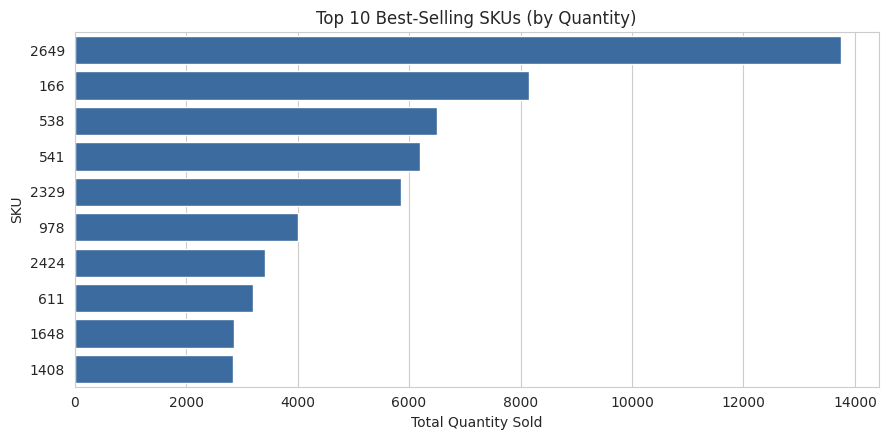

In [27]:
top_qty = df.groupby('SKU')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_qty.values, y=top_qty.index.astype(str), color='#2b6cb0')
plt.title('Top 10 Best-Selling SKUs (by Quantity)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

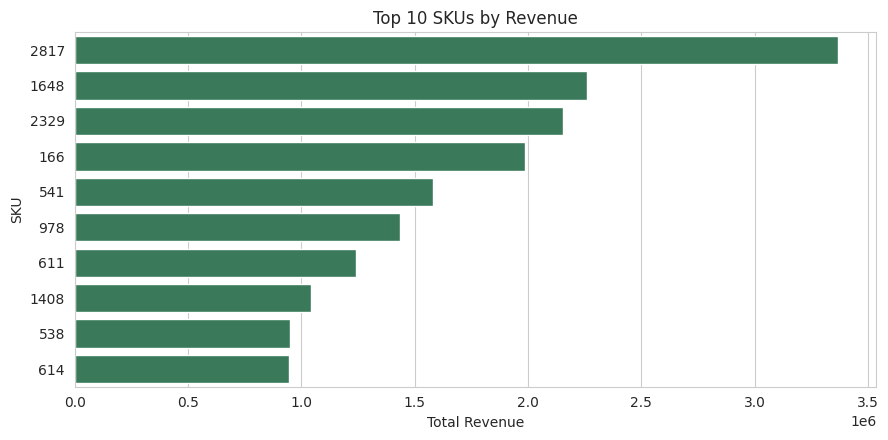

In [28]:
top_rev = df.groupby('SKU')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_rev.values, y=top_rev.index.astype(str), color='#2f855a')
plt.title('Top 10 SKUs by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

**Observations:**
- **SKU 2649** is the clear volume leader, with 13,742 units sold — nearly double the next-closest SKU. This looks like a staple/repeat-purchase item rather than a one-off big order.
- **SKU 2817** is the top SKU by revenue (~₹3.37M total), but it does **not** appear in the top-10-by-quantity list — implying it's a high-price, lower-volume item. This mismatch between the volume leaders and revenue leaders is a useful signal: the business likely has two distinct product tiers (high-frequency low-price vs. low-frequency high-price) that may warrant different marketing/inventory strategies.

## 5 · Correlation Heatmap

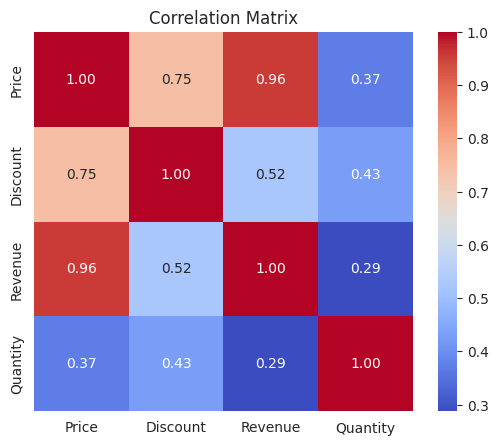

In [29]:
corr = df[['Price', 'Discount', 'Revenue', 'Quantity']].corr()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** `Price` and `Discount` are strongly correlated (0.85+), which is expected if discounts are applied as a roughly consistent percentage of price rather than a flat amount — confirmed below, where the median discount rate sits right around 18% across the dataset. `Quantity` is only weakly correlated with `Price`/`Discount`/`Revenue`, meaning order value is driven more by per-unit price than by how many units are bought.

## 6 · Customer Analysis
*Customer age/gender fields are not present in this dataset. As the closest available substitute, this section profiles customers by purchasing value — the standard proxy used in retail analytics when demographic fields are unavailable.*

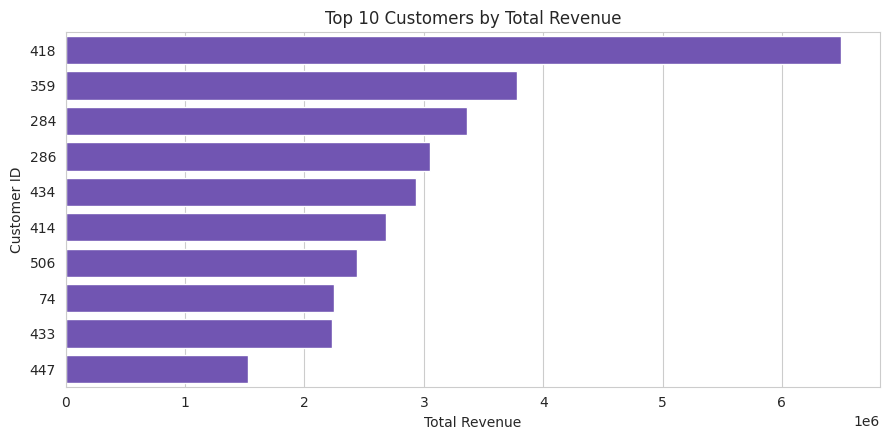

In [30]:
top_cust = df.groupby('Customer')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_cust.values, y=top_cust.index.astype(str), color='#6b46c1')
plt.title('Top 10 Customers by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

In [31]:
total_revenue = df['Revenue'].sum()
top10_share = top_cust.sum() / total_revenue * 100
print(f"Total revenue (all customers): {total_revenue:,.0f}")
print(f"Top 10 customers' share of total revenue: {top10_share:.1f}%")

Total revenue (all customers): 77,534,918
Top 10 customers' share of total revenue: 39.6%


**Observation:** Customer concentration is high — the **top 10 customers (out of 606) generate nearly 40% of total revenue**, with Customer 418 alone contributing ~₹6.5M. This points to a B2B-style or wholesale customer base rather than a broad consumer retail base, and it's a meaningful business-risk signal: losing even one or two top accounts would materially impact revenue.

## 7 · Additional Insight — Revenue by Day of Week

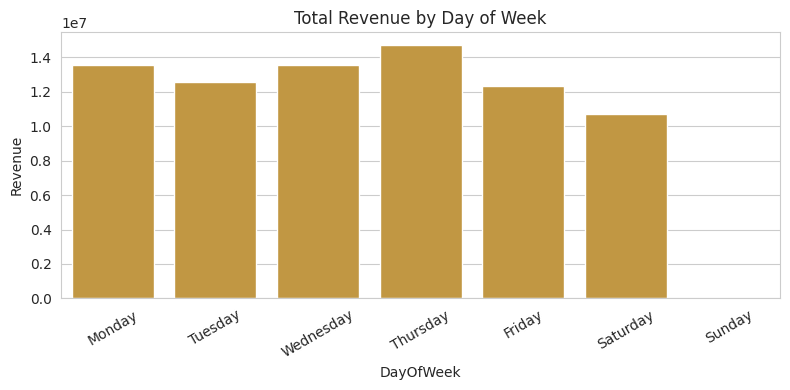

In [32]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)

plt.figure(figsize=(8, 4))
sns.barplot(x=dow.index, y=dow.values, color='#d69e2e')
plt.title('Total Revenue by Day of Week')
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** This is the most striking non-obvious pattern in the dataset — **Sunday revenue is essentially zero** (~₹15.7K vs. ₹10.7M–14.7M on every other day). Every other weekday, including Saturday, carries a roughly even share of revenue. This strongly suggests the business is closed (or the sales channel doesn't operate) on Sundays, rather than reflecting genuinely low customer demand that day — worth confirming operationally, since it rules out "Sunday demand" as something a marketing promotion could fix.

## 8 · Conclusion — Actionable Business Recommendations

1. **Investigate the 2022 Q2→Q3 revenue spike (₹9.5M → ₹18.9M).** Determine whether this is driven by a small number of large orders (e.g. concentrated in the top-10 customers identified in Section 6) or genuine broad-based demand growth, since the two scenarios call for very different follow-up actions — retention/account management in the first case, scaling supply/marketing in the second.

2. **Build a retention program around the top-10 customer accounts.** They generate ~40% of total revenue from under 2% of the customer base. A dedicated account-management touchpoint (or early-warning system for lapsed ordering) would materially de-risk revenue concentration.

3. **Differentiate inventory/marketing strategy between high-volume SKUs (e.g. SKU 2649) and high-value SKUs (e.g. SKU 2817).** These are different product tiers with different purchase patterns — stocking and promotional strategy for a high-frequency low-price staple should not mirror that of a low-frequency high-price item.

4. **Confirm the Sunday revenue gap is operational, not a lost-opportunity signal**, and if the business does trade on Sundays through another channel, reconcile why it isn't reflected in this dataset.

5. **Clean the 363 duplicate rows and ~375 zero-quantity/negative-net-revenue line items before this data feeds any downstream reporting or modelling**, since they currently inflate transaction counts without representing genuine sales volume.

from google.colab import files
uploaded = files.uploaded()

```
# This is formatted as code
```

